# CLIP ZERO-SHOT

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Saving tuan.png to tuan.png


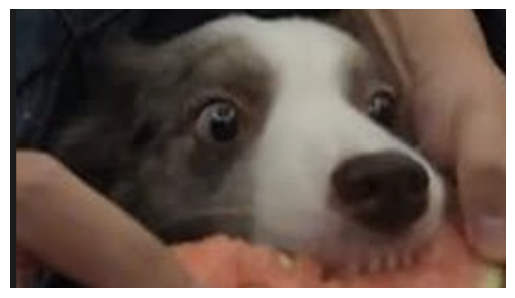

分类结果：
a photo of a cat: 0.0081
a photo of a dog: 0.9572
a photo of a car: 0.0015
a photo of a flower: 0.0018
a photo of a person: 0.0314

最终预测： a photo of a dog


In [2]:
!pip -q install transformers pillow matplotlib

import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
from google.colab import files

# 1. 设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 2. 加载模型
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
model.eval()

# 3. 上传图片
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

# 4. 显示图片
plt.imshow(image)
plt.axis("off")
plt.show()

# 5. 候选类别
candidate_labels = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a photo of a flower",
    "a photo of a person"
]

# 6. 预处理
inputs = processor(
    text=candidate_labels,
    images=image,
    return_tensors="pt",
    padding=True
).to(device)

# 7. 推理
with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

# 8. 输出
probs = probs[0].cpu().numpy()

print("分类结果：")
for label, prob in zip(candidate_labels, probs):
    print(f"{label}: {prob:.4f}")

best_idx = probs.argmax()
print("\n最终预测：", candidate_labels[best_idx])